> ### 🔓 ¿Te atoras en algún 👉 TU TURNO?
> Abre la **versión RESUELTA** que te compartió tu profe. 👉 _[ link de la solución ]_

# 🧾 PROYECTO FINAL · EL COMANDERO — el mesero de WhatsApp de Jardín la Gloria ☕

Vas a construir un **mesero automático de WhatsApp** que junta **TODO** lo del curso:

| Paso | Concepto del curso | Qué hace en El Comandero |
|---|---|---|
| ① | **Fine-tuning** (DistilBERT + LoRA) | Lee el mensaje y decide qué es: **PEDIDO / PREGUNTA / QUEJA / OTRO** |
| ② | **RAG** (sentence-transformers) | Busca el **dato real** en el menú (precio, horario, si hay leche de avena…) |
| ③ | **Prompt** (Groq · gpt-oss-20b) | **Redacta** la respuesta con voz de mesero buena onda |
| ④ | **Evaluación** (matriz + Groq-juez) | Mide **qué tan bien** clasificó y si **citó bien** el menú |

> 🧠 **La idea clave:** el clasificador decide **quién contesta**. PEDIDO y PREGUNTA → los atiende la IA (con el dato real). QUEJA y OTRO → **se pasan a un humano** (la IA no inventa ni improvisa en lo delicado).

### 🗺️ El plan (a botones)
`Instalar → Llave de Groq → Menú → RAG → Dataset → Clasificador (antes) → LoRA + Entrenar → (después + matriz) → Voz del mesero → Juez → App Gradio`

> ✅ Corre en **CPU**. La única llave es **GROQ_API_KEY** (gratis en groq.com).

Busca los **👉 TU TURNO** (mensajes que TÚ escribes). Corre cada celda con **▶** en orden. 🚀

## 🔧 Paso 1 · Instalar las herramientas
Un solo `pip` baja todo: Hugging Face (entrenar + clasificar), sentence-transformers (RAG), Groq (redactar) y Gradio (la app).

In [18]:
%%capture
# torchao de Colab a veces choca con peft → lo quitamos para evitar el error
!pip uninstall -y torchao
!pip install -q transformers peft datasets sentence-transformers groq "gradio>=6,<7"

## 🔑 Paso 2 · Pega tu llave de Groq
Groq es el **cerebro que redacta** las respuestas. Saca tu llave gratis en **groq.com → API Keys** y pégala cuando te la pida (no se guarda en el notebook).

> 🧠 **Quién hace qué:** Groq **redacta**. El **dato** (precio, horario) lo busca el **RAG** local del Paso 4 — eso es gratis y no usa internet de Groq.

In [19]:
import os, time
from getpass import getpass
from groq import Groq

from google.colab import userdata
groq_client= Groq(api_key=userdata.get('key_cHALLENGES'))
print('Cliente de Groq inicializado correctamente')

GROQ_MODEL = "openai/gpt-oss-20b"   # modelo abierto, el mismo de la Clase 2

def preguntar_a_groq(prompt, temperatura=0.4):
    """Manda un prompt a Groq y regresa el texto. Si el plan gratis te frena, espera y reintenta una vez."""
    for intento in (1, 2):
        try:
            r = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperatura,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if intento == 1:
                print("⏳ Groq se tardó o te frenó; espero 5 seg y reintento…")
                time.sleep(5)
            else:
                return f"(No pude contestar: {type(e).__name__}. Revisa tu llave o espera un minuto.)"

print("Groq listo ✅  ·  modelo:", GROQ_MODEL)

Cliente de Groq inicializado correctamente
Groq listo ✅  ·  modelo: openai/gpt-oss-20b


## 📋 Paso 3 · El menú de Jardín la Gloria (los datos del negocio)
Este texto es **la única verdad** del mesero: precios, horarios, promos, wifi, envíos. El mesero **jamás** inventará algo que no esté aquí.

In [30]:
MENU = """JARDIN LA GLORIA ☕ — Datos del negocio
Si tengo que elegir entre el cielo y el infierno, me quedo EN LA GLORIA.
Jardín La Gloria
Recuerda, no es más feliz quien lo tiene todo, sino quien está EN LA GLORIA.

== Redes Sociales y Sitio Web ==
•	Instagram: @jardin.la_gloria
•	Facebook: Jardín La Gloria
•	Sitio Web: www.jardinlagloria.com
•	wifi: pregunta directamente al personal de servicio

== Horario ==
Jueves a Sábado abrimos de 11:00 a 23:00 hrs
Domingos abrimos de 11:00 a 20:00. hrs
La cocina caliente (comida) cierra 60 minutos antes del cierre.

== Menú - Jardín La Gloria ==

== PURO SABOR (HAMBURGUESAS) ==
•	Hamburguesa Sencilla: 250 g de carne 100% de res, queso gouda, queso americano, jitomate, lechuga y aderezos — $110
•	Hamburguesa con Tocino: 250 g de carne 100% de res, mermelada de tocino, queso gouda, queso americano, jitomate, lechuga, tocino y aderezos — $125
•	Guacamole Burguer: 250 g de carne 100% de res, guacamole, queso gouda, queso americano, jitomate, lechuga y aderezos — $140
•	Hamburguesa Especial: 250 g de carne 100% de res, camarones, tocino, queso crema, queso gouda, jitomate, lechuga y aderezo de chipotle y guacamole — $155
•	Extra: Bañala con queso cheddar por +$20

== DELICIAS DEL MAR ==
•	Tostada de Atún: Lomo de atún bañado en mix de salsas y limón, acompañado con terso de aguacate y cebolla encurtida — $60
•	Sashimi: Finos cortes de lomo de atún bañados en mix de salsas, con un toque de terso de aguacate — $90
•	Ceviche: Lomo de atún bañado en mix de salsas y limón, acompañado con terso de aguacate y cebolla encurtida — $110
•	Tostada de Camarón: Camarones bañados en mix de salsas, limón y vegetales frescos — $75
•	Agua Chile Básico: Pescado o atún marinado en mix de salsas con limón, acompañado de vegetales frescos (Serrano o Habanero) — $120
•	Coctel de Camarón: Camarones con el auténtico sabor de La Gloria — $175
•	Agua Chile de Camarón: Camarón encurtido en jugo de limón, acompañado de vegetales frescos (Serrano o Habanero) — $175
•	Tostada de Aguachile: $95
•	Agua Chile Mega: $490 (agrega camarones por +$40)

== PARA EL ANTOJO / BOTANAS ==
•	Tazón Chicharrones: $20
•	Cacahuates: $40
•	Cacahuates Preparados: $45
•	Pepinos Preparados: $45
•	Mega Tazón Chicharrones: $50
•	Papas Preparadas: $50
•	Papas a la Francesa: $70 (agrega queso cheddar por +$20)
•	Nachos: $75
•	Boneless: $90
•	Alitas (BBQ / Búfalo / Habanero La Gloria): $90
•	Jalapeño Poppers: $100

== SHOTS Y CERVEZAS ==
Tequilas & Mezcal
•	Centenario Reposado — $70
•	Centenario Plata — $70
•	Azul Centenario — $50
•	1800 Cristalino — $90
•	Mezcal — $70

== Cervezas ==
•	Media Sola — $35
•	Caguama Sola — $75
•	Cerveza de Barril (Media / 1 Litro / 1/2 Lt / Macetazo 1 Lt / Cuartito) — $25 - $180
•	Importadas (Miller, Heineken, Miller Latón) — $40 - $120

== PREPARADAS Y CLAMATOS ==
•	Chelada: 1/2 litro: $50 / $85. 1 litro: $50 - $90.
•	Michelada: 1/2 litro: $65 / $95. 1 litro: $55 - $90.
•	Clamato: Media: $70. Caguama: $110. 1/2 litro: $75 / $115. 1 litro: $90 - $100.
•	Clamato Marinero (1/2 docena de camarones): Media: $115. Caguama: $160. 1/2 litro: $120 / $175. 1 litro: $155 - $210.
•	Clamato Especial: Media: $150. Caguama: $200.
•	Cantaritos (Azul / Centenario / 1800): 1/2 litro: $95 - $125. 1 litro: $180 - $225. 6 litros: $1,000 - $1,500. 12 litros: $1,800 - $2,500.

== LAS DEL JARDÍN (CÓCTELES CON ALCOHOL) ==
•	Balazo (Levanta Crudas): Ostiones, camarones y el sabor único de Jardín La Gloria — $75
•	Rosita: Mix de cítricos, con el escarchado único de la casa, tequila, sal y limón — $90
•	Gerbera: Extracto de naranja, toque cítrico y tequila — $90
•	Margarita: Escarchado mixto, notas cítricas y tequila — $90
•	Violeta: Vino tinto, con notas cítricas — $90
•	Cuba: Ron o Tequila, con el refresco de tu elección — $90
•	Azucena: Crema de coco, ron blanco, extracto de piña y toque cítrico — $95
•	Mojito: Ron blanco con notas cítricas y menta fresca (Tradicional, Frutos Rojos) — $95
•	Mezcalita: Mezcal artesanal mezclado con fruta natural (Jamaica, Guayaba, Frutos Rojos, Tropical) — $95
•	Cantarito: Tradición mexicana, jugo de limón, naranja y toronja, toque de sal y refresco — $95
•	Cantarito Jumbo (5 lts.): $1000
•	Mega Cantarito (12 lts.): $1800

== LAS DEL JARDÍN (SIN ALCOHOL) ==
•	Agua — $20
•	Refresco / Peñafiel Sabores — $30 / $40
•	Heineken 0.0 — $35
•	Limonada / Naranjada / Paloma — $40
•	Limonada Frutos Rojos / Clamato Mineral — $50
•	Mineral Prep. — $45
•	Mojito Sin Alcohol — $55

== EXTRAS / ADICIONALES ==
•	Tostadas: $10
•	Orden de Limones: $20
•	Vasos / Preparaciones extra: $15 - $85 (Chelado, Michelado, Clamato, Marinero)
•	Desechable: $5 """
print("Menú cargado ✅ ·", len(MENU), "caracteres")

Menú cargado ✅ · 4625 caracteres


## 🔎 Paso 4 · RAG — hacer el menú *buscable*
Partimos el menú en **secciones** (Horarios, Precios, Wifi, Envíos…) y las convertimos en **embeddings** (numeritos) para poder buscar por significado, no por palabra exacta.

> 🧠 **Concepto → RAG:** `buscar()` toma la pregunta del cliente y regresa las **secciones más parecidas**. Así el mesero contesta con el dato real.

In [31]:
from sentence_transformers import SentenceTransformer, util

# Cortamos el menú por secciones (cada bloque "== TÍTULO ==" con sus líneas)
def trocear(texto):
    chunks, actual = [], []
    for linea in texto.split("\n"):
        if linea.startswith("== ") and linea.endswith(" =="):
            if actual: chunks.append("\n".join(actual).strip())
            actual = [linea]
        else:
            actual.append(linea)
    if actual: chunks.append("\n".join(actual).strip())
    return [c for c in chunks if c]

secciones = trocear(MENU)

# Modelo de embeddings MULTILINGÜE (entiende español)
buscador = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb_secciones = buscador.encode(secciones, convert_to_tensor=True)

def buscar(pregunta, k=3):
    """Regresa las k secciones del menú más parecidas a la pregunta."""
    emb_q = buscador.encode(pregunta, convert_to_tensor=True)
    hits = util.semantic_search(emb_q, emb_secciones, top_k=k)[0]
    return [secciones[h["corpus_id"]] for h in hits]

print(len(secciones), "secciones listas para buscar ✅")
print("\nEjemplo — busco '¿tienen wifi?':\n")
print(buscar("¿tienen wifi?", k=1)[0])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

13 secciones listas para buscar ✅

Ejemplo — busco '¿tienen wifi?':

== Redes Sociales y Sitio Web ==
•	Instagram: @jardin.la_gloria
•	Facebook: Jardín La Gloria
•	Sitio Web: www.jardinlagloria.com
•	wifi: pregunta directamente al personal de servicio


## 🎨 Paso 5 · El dataset de mensajes (4 clases)
Mensajes de WhatsApp con su etiqueta: **PEDIDO / PREGUNTA / QUEJA / OTRO**. Y un set de **prueba** aparte (el modelo NO lo ve al entrenar) para medir de verdad.

> ### ✋ AQUÍ TE TOCA A TI (2 renglones)
> En la celda de abajo hay **2 renglones que dicen `👉 TU TURNO`**. Borra ese texto y escribe TÚ el mensaje **entre las comillas**.
> ⚠️ No cambies la etiqueta de la derecha (`"PEDIDO"`, `"QUEJA"`) ni borres las comillas ni la coma del final.

In [32]:
from datasets import Dataset

CLASES = ['PEDIDO', 'PREGUNTA', 'QUEJA', 'OTRO']
clase2id = {c: i for i, c in enumerate(CLASES)}
id2clase = {i: c for i, c in enumerate(CLASES)}

mensajes = [
    ('¿A qué hora abren mañana?', 'PREGUNTA'),
('Me gustarias pedir dos hamburguesas sencillas para llevar.', 'PEDIDO'),
('La comida me llegó completamente fría y tardó más de una hora.', 'QUEJA'),
('Muchas gracias por la excelente atención de hoy.', 'OTRO'),
('¿Tienen servicio a domicilio en esta zona?', 'PREGUNTA'),
('Ponme una orden de alitas BBQ y unas papas a la francesa, por favor.', 'PEDIDO'),
('El mesero me cobró cosas que no consumimos en la cuenta.', 'QUEJA'),
('Solo quería comentar que el lugar está muy bonito.', 'OTRO'),
('¿Aceptan tarjetas de crédito o solo efectivo?', 'PREGUNTA'),
('Quiero pedir una michelada de litro y una tostada de atún.', 'PEDIDO'),
('Hay un pelo en mi plato, exijo que me lo cambien.', 'QUEJA'),
('Ojalá pongan más música en español la próxima vez.', 'OTRO'),
('¿Cuentan con opciones vegetarianas en el menú?', 'PREGUNTA'),
('Me das dos cantaritos de litro y unos nachos con queso.', 'PEDIDO'),
('El baño estaba muy sucio y no había papel.', 'QUEJA'),
('Pase por fuera del local y me llamó mucho la atención la fachada.', 'OTRO'),
('¿Tienen estacionamiento o valet parking?', 'PREGUNTA'),
('Tráeme una hamburguesa especial con extra de queso cheddar.', 'PEDIDO'),
('La carne de la hamburguesa estaba completamente cruda.', 'QUEJA'),
('Le envío un saludo al chef, todo quedó delicioso.', 'OTRO'),
('¿Se necesita hacer reservación para ir el fin de semana?', 'PREGUNTA'),
('Agrégame un clamato preparado y unos boneless a la orden.', 'PEDIDO'),
('Llevamos media hora esperando y ni siquiera nos han tomado la bebida.', 'QUEJA'),
('Mañana es el cumpleaños de un amigo y pensamos ir allá.', 'OTRO'),
('¿Cuál es el precio del Mega Cantarito de 12 litros?', 'PREGUNTA'),
('Mándame una tostada de camarón y una agua de limón.', 'PEDIDO'),
('Pedí la salsa habanera aparte y la le pusieron directo a la comida.', 'QUEJA'),
('Vi su publicación en Instagram y por eso los busqué.', 'OTRO'),
('¿Tienen promociones o cumpleaños este mes?', 'PREGUNTA'),
('Me pones tres caguamas preparadas y una orden de cacahuates.', 'PEDIDO'),
('El aire acondicionado está demasiado fuerte y hace mucho frío.', 'QUEJA'),
('Espero que tengan mucho éxito con su negocio.', 'OTRO'),
('¿Tienen terraza para fumadores?', 'PREGUNTA'),
('Quiero encargar un paquete de hamburguesas para pasar a recoger.', 'PEDIDO'),
('Me dieron mal el cambio al pagar en efectivo.', 'QUEJA'),
('Apenas voy en camino hacia el restaurante con mi familia.', 'OTRO'),
('¿Manejan menú infantil para niños?', 'PREGUNTA'),
('Tráenos una ronda de shots de tequila para la mesa.', 'PEDIDO'),
('El sonido de la música está tan alto que no se puede ni hablar.', 'QUEJA'),
('Guárdame una mesa cerca de la entrada si es posible.', 'OTRO'),
('Me gustaría pedir tres hamburguesas sencillas para llevar.', 'PEDIDO'),
('Quiero una hamburguesa con tocino y unas papas a la francesa.', 'PEDIDO'),
('Me gustaría pedir un ceviche y una tostada de camarón.', 'PEDIDO'),
('Quiero un agua chile de camarón y una cerveza de barril.', 'PEDIDO'),
('Me gustaría pedir unos boneless y unas alitas BBQ.', 'PEDIDO'),
('Quiero un cantarito de un litro y una hamburguesa especial.', 'PEDIDO'),
('Me gustaría pedir un mojito sin alcohol y unos nachos.', 'PEDIDO'),
('Quiero una tostada de atún y un coctel de camarón.', 'PEDIDO'),
('¿Cuánto cuesta la hamburguesa sencilla?', 'PREGUNTA'),
('¿Qué ingredientes lleva la hamburguesa con tocino?', 'PREGUNTA'),
('¿Cuánto cuesta agregar queso cheddar a las papas?', 'PREGUNTA'),
('¿Qué opciones de aguachile tienen?', 'PREGUNTA'),
('¿Cuánto cuesta el coctel de camarón?', 'PREGUNTA'),
('¿Qué días está abierto Jardín La Gloria?', 'PREGUNTA'),
('¿A qué hora cierran los domingos?', 'PREGUNTA'),
('¿A qué hora deja de funcionar la cocina?', 'PREGUNTA'),
('¿Cuánto cuesta una caguama sola?', 'PREGUNTA'),
('¿Cuánto cuesta un cantarito de 12 litros?', 'PREGUNTA'),
('¿Tienen bebidas sin alcohol?', 'PREGUNTA'),
('¿Cuál es el precio del mojito sin alcohol?', 'PREGUNTA'),
('Me cobraron un precio diferente al que aparece en el menú por la hamburguesa.', 'QUEJA'),
('Mi hamburguesa con tocino llegó sin tocino.', 'QUEJA'),
('Pedí una hamburguesa especial y no le pusieron los ingredientes que corresponden.', 'QUEJA'),
('Mi pedido de alitas llegó equivocado.', 'QUEJA'),
('Pedí un aguachile de camarón y mi pedido llegó incompleto.', 'QUEJA'),
('Mi bebida preparada no llegó como la había pedido.', 'QUEJA'),
('Pedí papas con queso cheddar y no le agregaron el queso.', 'QUEJA'),
('Mi comida llegó fría y quiero reportarlo.', 'QUEJA'),
('Me cobraron un extra que no solicité.', 'QUEJA'),
('Mi pedido de tostadas llegó incompleto.', 'QUEJA'),
('Quiero saber si tienen wifi.', 'OTRO'),
('¿Cuál es el sitio web de Jardín La Gloria?', 'OTRO'),
('¿Cuál es el Instagram de Jardín La Gloria?', 'OTRO'),
('¿Cómo aparece Jardín La Gloria en Facebook?', 'OTRO'),
('¿Cuánto cuesta una orden extra de limones?', 'OTRO'),
('¿Cuánto cuesta una tostada adicional?', 'OTRO'),
('¿Cuánto cuesta un vaso o preparación extra?', 'OTRO'),
('¿Cuánto cuesta el desechable?', 'OTRO'),
('¿Qué sabores de alitas tienen?', 'OTRO'),
('¿Qué tipos de tequila y mezcal tienen disponibles?', 'OTRO')
]

# Mensajes de PRUEBA (held-out): NO están en el entrenamiento
PRUEBA = [
    ('¿Tienen espacio disponible para un grupo de 15 personas hoy?', 'PREGUNTA'),
    ('Me preparas un aguachile básico de habanero y un refresco, por favor.', 'PEDIDO'),
    ('La cerveza que me sirvieron ya estaba tibia y sin gas.', 'QUEJA'),
    ('En encontré su restaurante buscando lugares para cenar en la zona.', 'OTRO'),
    ('¿Permiten el acceso con mascotas en la terraza?', 'PREGUNTA'),
    ('Anota en mi cuenta una orden de jalapeño poppers y una limonada.', 'PEDIDO'),
    ('Olvidé un saco colgado en la silla de mi mesa hace un momento.', 'QUEJA'),
    ('Voy a recomendar mucho este lugar con mis compañeros de trabajo.', 'OTRO'),
    ('¿El aguachile lleva tostadas o galletas saladas incluidas?', 'PREGUNTA'),
    ('Por favor tráeme un tazón de chicharrones y dos mediecitas frías.', 'PEDIDO'),
    ('Me gustaría pedir una Guacamole Burguer con queso cheddar extra.', 'PEDIDO'),
    ('Quiero una hamburguesa especial y una Margarita.', 'PEDIDO'),
    ('Me gustaría pedir un sashimi y una orden de limones.', 'PEDIDO'),
    ('Quiero un agua chile básico de atún y un mojito de frutos rojos.', 'PEDIDO'),
    ('Me gustaría pedir una media de clamato marinero y unas papas preparadas.', 'PEDIDO'),
    ('Quiero un cantarito de 6 litros para compartir.', 'PEDIDO'),
    ('¿Cuánto cuesta la Guacamole Burguer?', 'PREGUNTA'),
    ('¿Qué ingredientes tiene la hamburguesa especial?', 'PREGUNTA'),
    ('¿Cuánto cuesta el sashimi de atún?', 'PREGUNTA'),
    ('¿Cuánto cuesta una tostada de aguachile?', 'PREGUNTA'),
    ('¿Qué tamaños de cantaritos tienen?', 'PREGUNTA'),
    ('¿Cuánto cuesta una Margarita?', 'PREGUNTA'),
    ('¿Cuánto cuesta la Heineken 0.0?', 'PREGUNTA'),
    ('¿Cuánto cuesta el clamato marinero en un litro?', 'PREGUNTA'),
    ('Mi pedido de camarones no corresponde con lo que solicité.', 'QUEJA'),
    ('La bebida que recibí no corresponde con la que pedí.', 'QUEJA'),
    ('Pedí una hamburguesa con queso cheddar y no me lo agregaron.', 'QUEJA'),
    ('Me entregaron una preparación de clamato diferente a la que pedí.', 'QUEJA'),
    ('¿Qué tipos de mojito tienen?', 'OTRO'),
    ('¿Qué sabores de mezcalita ofrecen?', 'OTRO')

]

train_ds = Dataset.from_dict({
    "text":   [t for t, c in mensajes],
    "labels": [clase2id[c] for t, c in mensajes],
})
print(len(mensajes), "mensajes de entrenamiento y", len(PRUEBA), "de prueba ✅")
print("Clases:", CLASES)

80 mensajes de entrenamiento y 30 de prueba ✅
Clases: ['PEDIDO', 'PREGUNTA', 'QUEJA', 'OTRO']


## 🅰️ Paso 6 · El clasificador ANTES de afinar
Cargamos **DistilBERT multilingüe** con una "cabecita" de 4 opciones. Como está **sin entrenar**, va a adivinar (aciertos bajitos).

In [34]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging
logging.set_verbosity_error()

nombre = "distilbert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(nombre)
modelo = AutoModelForSequenceClassification.from_pretrained(
    nombre, num_labels=4, id2label=id2clase, label2id=clase2id)

def tok(b): return tokenizer(b["text"], truncation=True, padding="max_length", max_length=64)
train_tok = train_ds.map(tok, batched=True)

def clasificar(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, max_length=64).to(modelo.device)
    modelo.eval()
    with torch.no_grad():
        logits = modelo(**inputs).logits
    return id2clase[int(logits.argmax(dim=-1))]

def aciertos():
    return round(100 * sum(clasificar(t) == c for t, c in PRUEBA) / len(PRUEBA))

antes_pred = {t: clasificar(t) for t, c in PRUEBA}
antes_acc = aciertos()
print("Aciertos ANTES:", antes_acc, "%  (adivinando, como debe ser)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Aciertos ANTES: 37 %  (adivinando, como debe ser)


## 🧩 Paso 7 · Ponle LoRA y entrena
LoRA entrena solo unas "perillas nuevas" + la cabecita (menos del 1% del modelo). Barato, rápido y estable.

In [35]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer

config_lora = LoraConfig(
    task_type="SEQ_CLS", r=8, lora_alpha=16,
    target_modules=["q_lin", "v_lin"], lora_dropout=0.05,
    modules_to_save=["pre_classifier", "classifier"],  # ¡entrena también la cabecita!
)
modelo = get_peft_model(modelo, config_lora)
modelo.print_trainable_parameters()

args = TrainingArguments(
    output_dir="/content/comandero", num_train_epochs=40,
    per_device_train_batch_size=4, learning_rate=5e-4,
    logging_steps=10, report_to="none",
)
trainer = Trainer(model=modelo, args=args, train_dataset=train_tok)
trainer.train()
print("¡Entrenado! 🎉")

trainable params: 741,124 || all params: 136,068,872 || trainable%: 0.5447


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '1.541', 'grad_norm': '5.462', 'learning_rate': '0.0004944', 'epoch': '0.5'}
{'loss': '1.288', 'grad_norm': '3.983', 'learning_rate': '0.0004881', 'epoch': '1'}
{'loss': '0.9376', 'grad_norm': '7.049', 'learning_rate': '0.0004819', 'epoch': '1.5'}
{'loss': '0.8816', 'grad_norm': '4.225', 'learning_rate': '0.0004756', 'epoch': '2'}
{'loss': '0.718', 'grad_norm': '6.281', 'learning_rate': '0.0004694', 'epoch': '2.5'}
{'loss': '0.53', 'grad_norm': '3.455', 'learning_rate': '0.0004631', 'epoch': '3'}
{'loss': '0.5328', 'grad_norm': '16.46', 'learning_rate': '0.0004569', 'epoch': '3.5'}
{'loss': '0.403', 'grad_norm': '1.878', 'learning_rate': '0.0004506', 'epoch': '4'}
{'loss': '0.2253', 'grad_norm': '2.53', 'learning_rate': '0.0004444', 'epoch': '4.5'}
{'loss': '0.2216', 'grad_norm': '4.34', 'learning_rate': '0.0004381', 'epoch': '5'}
{'loss': '0.1723', 'grad_norm': '0.04585', 'learning_rate': '0.0004319', 'epoch': '5.5'}
{'loss': '0.449', 'grad_norm': '0.7034', 'learning_rate': '

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'loss': '6.112e-05', 'grad_norm': '0.001132', 'learning_rate': '0.0001819', 'epoch': '25.5'}
{'loss': '0.0004128', 'grad_norm': '0.003301', 'learning_rate': '0.0001756', 'epoch': '26'}
{'loss': '9.053e-05', 'grad_norm': '0.0006825', 'learning_rate': '0.0001694', 'epoch': '26.5'}
{'loss': '4.247e-05', 'grad_norm': '0.002624', 'learning_rate': '0.0001631', 'epoch': '27'}
{'loss': '0.0002159', 'grad_norm': '0.0109', 'learning_rate': '0.0001569', 'epoch': '27.5'}
{'loss': '6.922e-05', 'grad_norm': '0.001118', 'learning_rate': '0.0001506', 'epoch': '28'}
{'loss': '0.0001052', 'grad_norm': '0.0004328', 'learning_rate': '0.0001444', 'epoch': '28.5'}
{'loss': '0.0001212', 'grad_norm': '0.0009152', 'learning_rate': '0.0001381', 'epoch': '29'}
{'loss': '6.243e-05', 'grad_norm': '0.0009651', 'learning_rate': '0.0001319', 'epoch': '29.5'}
{'loss': '0.0001603', 'grad_norm': '0.004464', 'learning_rate': '0.0001256', 'epoch': '30'}
{'loss': '8.988e-05', 'grad_norm': '0.0006772', 'learning_rate': '0.

## 🅱️ Paso 8 · DESPUÉS de afinar + la matriz de confusión (el momento 🤯)
Los **mismos** mensajes de prueba, ahora con el modelo afinado. Y una **matriz de confusión**: qué clase le atinó y en cuál se confundió.

Aciertos ANTES : 37 %
Aciertos DESPUÉS: 97 %

✅ [PREGUNTA] (real: PREGUNTA)  ¿Tienen espacio disponible para un grupo de 15 personas hoy?
✅ [PEDIDO] (real: PEDIDO)  Me preparas un aguachile básico de habanero y un refresco, por favor.
✅ [QUEJA] (real: QUEJA)  La cerveza que me sirvieron ya estaba tibia y sin gas.
✅ [OTRO] (real: OTRO)  En encontré su restaurante buscando lugares para cenar en la zona.
✅ [PREGUNTA] (real: PREGUNTA)  ¿Permiten el acceso con mascotas en la terraza?
✅ [PEDIDO] (real: PEDIDO)  Anota en mi cuenta una orden de jalapeño poppers y una limonada.
✅ [QUEJA] (real: QUEJA)  Olvidé un saco colgado en la silla de mi mesa hace un momento.
✅ [OTRO] (real: OTRO)  Voy a recomendar mucho este lugar con mis compañeros de trabajo.
✅ [PREGUNTA] (real: PREGUNTA)  ¿El aguachile lleva tostadas o galletas saladas incluidas?
✅ [PEDIDO] (real: PEDIDO)  Por favor tráeme un tazón de chicharrones y dos mediecitas frías.
✅ [PEDIDO] (real: PEDIDO)  Me gustaría pedir una Guacamole Burgue

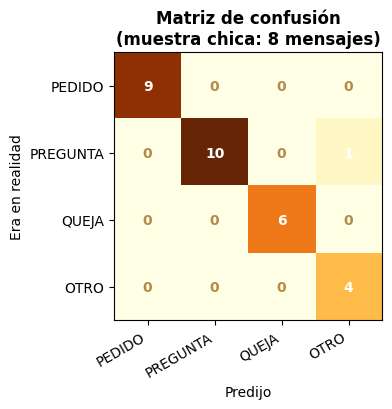


🏁 De 37% a 97% de aciertos con solo afinar. ✅


In [36]:
import matplotlib.pyplot as plt
import numpy as np

despues_pred = {t: clasificar(t) for t, c in PRUEBA}
despues_acc = aciertos()
print("Aciertos ANTES :", antes_acc, "%")
print("Aciertos DESPUÉS:", despues_acc, "%\n")

for t, c in PRUEBA:
    d = despues_pred[t]
    print(("✅" if d == c else "❌"), f"[{d}] (real: {c})  {t}")

# --- Matriz de confusión (muestra chica: 8 mensajes de prueba) ---
def matriz_confusion():
    M = np.zeros((4, 4), dtype=int)
    for t, c in PRUEBA:
        M[clase2id[c]][clase2id[despues_pred[t]]] += 1
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ax.imshow(M, cmap="YlOrBr")
    ax.set_xticks(range(4)); ax.set_xticklabels(CLASES, rotation=30, ha="right")
    ax.set_yticks(range(4)); ax.set_yticklabels(CLASES)
    ax.set_xlabel("Predijo"); ax.set_ylabel("Era en realidad")
    ax.set_title("Matriz de confusión\n(muestra chica: 8 mensajes)", weight="bold")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, M[i][j], ha="center", va="center",
                    color="white" if M[i][j] else "#b58b4c", weight="bold")
    fig.tight_layout()
    return fig

fig_matriz = matriz_confusion()
fig_matriz.savefig("/content/matriz.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\n🏁 De {antes_acc}% a {despues_acc}% de aciertos con solo afinar. ✅")

## 🗣️ Paso 9 · La voz del mesero (Prompt) + el pipeline completo
Aquí se junta todo: el clasificador decide **quién contesta**. Si es PEDIDO/PREGUNTA, el RAG busca el dato y **Groq redacta** con voz de mesero. Si es QUEJA/OTRO, **se pasa a un humano**.

In [37]:
SYSTEM_RESPUESTA = """Eres "El Comandero", el mesero de WhatsApp de Jardin la Gloria ☕. Tu Trabajo es responderle al cliente de forma breve, clara y bien buena onda.

REGLA DE ORO — SOLO EL CONTEXTO:
- Responde ÚNICAMENTE con la información del CONTEXTO del menú que se te entrega abajo. Es tu única fuente de verdad.
- NUNCA inventes precios, productos, horarios, promociones ni disponibilidad. Si un dato no está en el contexto, NO lo adivines.
- Si el cliente pregunta algo que NO viene en el contexto, dilo con honestidad y ofrécete a checarlo con alguien del equipo. Ejemplo: "Uy, ese dato no lo tengo a la mano, pero con gusto te lo confirma alguien del equipo 😊".
- Si el cliente hace un PEDIDO, confírmalo con lo que sí exista en el contexto (producto y precio tal cual aparecen).

VOZ DE MARCA (cómo hablas):
- Cálido, cercano y de tú, como mesero amigable pero respetuoso. Español mexicano suave ("claro que sí", "con gusto", "ok", "de acuerdo"). Sin "vos/dale/che" ni groserías.
- Breve: 1 a 3 frases. Nada de choro.
- 1 o 2 emojis por mensaje (☕ 😊 🧾 👍), sin exagerar.
- Cierra SIEMPRE ofreciendo ayuda o antojando algo ("¿Se te antoja algo más? 😊").

Usa exactamente los nombres y precios que trae el CONTEXTO. No agregues información de fuera. Responde solo con el mensaje para el cliente, sin explicar tu razonamiento.

CONTEXTO DEL MENÚ:
{contexto}

MENSAJE DEL CLIENTE:
{mensaje}"""

def responder_mesero(mensaje, contexto):
    """Groq redacta la respuesta usando SOLO el contexto del menú."""
    prompt = SYSTEM_RESPUESTA.replace("{contexto}", contexto).replace("{mensaje}", mensaje)
    return preguntar_a_groq(prompt, temperatura=0.4)

def atender(mensaje):
    """Pipeline completo. Regresa un dict con todo lo que pasó."""
    clase = clasificar(mensaje)
    if clase in ("QUEJA", "OTRO"):
        return {"clase": clase, "a_humano": True, "respuesta": None, "contexto": None}
    contexto = "\n\n".join(buscar(mensaje, k=3))          # RAG: top-3 secciones
    respuesta = responder_mesero(mensaje, contexto)        # Prompt: Groq redacta
    return {"clase": clase, "a_humano": False, "respuesta": respuesta, "contexto": contexto}

# Probamos con 2 mensajes del set de PRUEBA (el modelo NO los vio al entrenar):
for m, clase_real in [PRUEBA[2], PRUEBA[4]]:
    r = atender(m)
    print("💬", m)
    if r["a_humano"]:
        print("   →", r["clase"], "· 🙋 pasa a un humano\n")
    else:
        print("   →", r["clase"], "· 🧾", r["respuesta"], "\n")

💬 La cerveza que me sirvieron ya estaba tibia y sin gas.
   → QUEJA · 🙋 pasa a un humano

💬 ¿Permiten el acceso con mascotas en la terraza?
   → PREGUNTA · 🧾 Uy, ese dato no lo tengo a la mano, pero con gusto te lo confirma alguien del equipo 😊 ¿Se te antoja algo más? 



## 🧑‍⚖️ Paso 10 · El juez (Groq evalúa a Groq)
Otra vuelta de evaluación: el mesero responde y **otro Groq de juez** califica si **citó bien el menú** (1–5) y si el **tono** es de Chida Café. Al juez le damos también la **respuesta correcta**, para que pueda cachar cuando el mesero se equivocó de dato.

> ⚠️ **Tier gratis de Groq:** usamos **3 preguntas** (son 6 llamadas) para no toparnos con el límite.

In [38]:
import json as _json

PROMPT_JUEZ = """Eres un juez de calidad para "El Comandero", el mesero de WhatsApp de Jardin la Gloria ☕. Vas a calificar QUÉ TAN BIEN respondió el mesero, comparando su respuesta contra el dato real del menú.

Recibes tres cosas:
- PREGUNTA DEL CLIENTE: {pregunta}
- CONTEXTO DEL MENÚ (la verdad, la única fuente válida): {contexto}
- RESPUESTA DEL COMANDERO (lo que hay que calificar): {respuesta}

Califica DOS cosas, cada una del 1 al 5 (1 = pésimo, 5 = excelente):

1) uso_menu — ¿La respuesta usó bien el dato del CONTEXTO?
   - 5: usó el dato correcto (precio/producto/horario) exacto como en el contexto, sin inventar nada.
   - 3: parcialmente correcto o incompleto.
   - 1: inventó datos, se contradijo con el contexto o dio info falsa.
   - Si el dato NO estaba en el contexto y el mesero lo reconoció con honestidad (en vez de inventar), eso cuenta como bueno (4-5).

2) tono — ¿Sonó a Chida Café? (cálido, mexicano suave, breve, con 1-2 emojis, y cerró ofreciendo ayuda).
   - 5: cumple todo. 3: le falta algo (muy seco, sin cierre, o demasiado largo). 1: frío, robótico o fuera de marca.

Devuelve ÚNICAMENTE un JSON válido, sin texto extra antes ni después, con esta forma exacta:
{
  "uso_menu": <1-5>,
  "tono": <1-5>,
  "cito_dato_correcto": <true|false>,
  "comentario": "<una frase corta en español mexicano explicando la calificación>"
}

DATO CORRECTO SEGÚN EL MENÚ (úsalo para verificar si el mesero acertó): {esperada}"""
PREGUNTAS_JUEZ = [
    {'pregunta': '¿A qué hora abren los domingos?', 'esperada': 'Los domingos Jardin la Gloria abre de 11:00 a 20:00.'},
    {'pregunta': '¿Cuánto cuesta un capuchino?', 'esperada': 'No tenemos capuchino a la venta.'},
    {'pregunta': '¿Tienen wifi y cuál es la contraseña?', 'esperada': 'lo puedes preguntar directamente al personal de servicio.'},
]

def juzgar(pregunta, contexto, respuesta, esperada=""):
    prompt = (PROMPT_JUEZ.replace("{pregunta}", pregunta)
                         .replace("{contexto}", contexto)
                         .replace("{respuesta}", respuesta)
                         .replace("{esperada}", esperada))
    crudo = preguntar_a_groq(prompt, temperatura=0.0)
    try:
        ini, fin = crudo.find("{"), crudo.rfind("}")
        return _json.loads(crudo[ini:fin+1])
    except Exception:
        return {"uso_menu": None, "tono": None, "cito_dato_correcto": None, "comentario": crudo[:120]}

resultados_juez = []
for item in PREGUNTAS_JUEZ:
    ctx = "\n\n".join(buscar(item["pregunta"], k=3))
    resp = responder_mesero(item["pregunta"], ctx)
    v = juzgar(item["pregunta"], ctx, resp, item["esperada"])
    resultados_juez.append({"pregunta": item["pregunta"], "respuesta": resp, **v})
    print("❓", item["pregunta"])
    print("   🧾", resp)
    print("   🧑‍⚖️ uso_menu:", v.get("uso_menu"), "· tono:", v.get("tono"), "·", v.get("comentario"), "\n")

_notas = [r["uso_menu"] for r in resultados_juez if isinstance(r.get("uso_menu"), (int, float))]
promedio_menu = round(sum(_notas) / len(_notas), 1) if _notas else None
print("⭐ Promedio 'uso del menú':", promedio_menu, "/ 5")

❓ ¿A qué hora abren los domingos?
   🧾 Domingos abrimos de 11:00 a 20:00 hrs ☕. ¿Se te antoja algo más? 😊
   🧑‍⚖️ uso_menu: 5 · tono: 5 · Respuesta correcta y con tono amigable 

❓ ¿Cuánto cuesta un capuchino?
   🧾 Uy, ese dato no lo tengo a la mano, pero con gusto te lo confirma alguien del equipo 😊  
¿Se te antoja algo más? ☕️
   🧑‍⚖️ uso_menu: 4 · tono: 5 · Reconoce que no tiene el dato y ofrece ayuda, buen tono. 

❓ ¿Tienen wifi y cuál es la contraseña?
   🧾 Uy, ese dato no lo tengo a la mano, pero con gusto te lo confirma alguien del equipo 😊  
¿Se te antoja algo más?
   🧑‍⚖️ uso_menu: 5 · tono: 5 · Respuesta correcta y con tono amigable. 

⭐ Promedio 'uso del menú': 4.7 / 5


## ☕ Paso 11 · La app de Gradio (El Comandero en vivo)
La ventanita bonita: pega un mensaje de cliente y ve en vivo cómo clasifica, busca y contesta — más la pestaña de evaluación. Al correr, Colab te da un **link público** (`share=True`).

In [39]:
import os
import gradio as gr

EMOJI = {"PEDIDO":"🧾","PREGUNTA":"❓","QUEJA":"😕","OTRO":"💬"}
COLOR = {"PEDIDO":"#6F8F5E","PREGUNTA":"#C98A3B","QUEJA":"#C0562F","OTRO":"#8A7A6D"}
EJEMPLOS_UI = [
    '¿Se puede pagar la cuenta dividida entre varias tarjetas?',
'Quiero un cantarito de un litro, por favor.',
'Quiero un Mojito de frutos rojos y una Mezcalita de guayaba, por favor.',
'¿Venden botellas completas de tequila o solo por copa y shot?',
'Quiero una Caguama Sola y una orden de cacahuates, por favor.',
'Por favor tráenos un agua chile básico de pescado para compartir.',
'Quiero una Azucena y una orden de jalapeño poppers, por favor.',
'Me gustaría pedir una hamburguesa sencilla y una limonada, por favor.',
'¿Cuánto cuesta la hamburguesa especial con camarones y tocino?',
'¿Qué opciones de sabores tienen para las limonadas?',
'¿El cantarito de 5 litros tiene algún sabor o preparación específica?',
'¿Cuánto cuesta una media de clamato especial?',
'Mi hamburguesa llegó sin queso y eso no fue lo que pedí.',
'Pedí una orden de boneless y me entregaron alitas en su lugar.',
'Me cobraron de más por las papas a la francesa y quiero reportarlo.',
'La orden de aguachile que recibí está incompleta y quiero presentar una queja.'
]

def badge_html(clase):
    c = COLOR[clase]
    return (f'<div style="display:inline-block;padding:8px 18px;border-radius:999px;'
            f'background:{c};color:#fff;font-weight:800;font-size:18px;'
            f'box-shadow:0 3px 10px {c}55;">{EMOJI[clase]} {clase}</div>')

HUMANO_HTML = ('<div style="background:#F7E6DF;border:2px solid #C0562F;border-radius:16px;'
               'padding:18px 20px;color:#7a2e18;font-size:16px;">🙋 <b>Esto se lo paso a un '
               'humano del equipo</b> — un integrante del equipo te dara respuesta en un momento. 🤎</div>')

# Lo que se ve ANTES de la primera orden (si no, la tarjeta se ve vacía y parece rota)
ESPERANDO = ('<div style="padding:22px 18px;color:#A67B5B;font-size:16px;text-align:center;">'
             '☕ Escribe un mensaje del cliente (o pica un ejemplo) y dale a '
             '<b>Tomar la orden</b>.<br>Aquí te digo qué tipo de mensaje es y qué contestar.</div>')

def clasificar_con_probs(mensaje):
    inputs = tokenizer(mensaje, return_tensors="pt", truncation=True, max_length=64).to(modelo.device)
    modelo.eval()
    with torch.no_grad():
        probs = modelo(**inputs).logits.softmax(dim=-1)[0]
    dic = {id2clase[i]: float(probs[i]) for i in range(4)}
    clase = max(dic, key=dic.get)
    return clase, dic

def ui_atender(mensaje):
    if not mensaje or not mensaje.strip():
        return (ESPERANDO, gr.update(value={}, visible=False), "",
                gr.update(visible=False), gr.update(value="", visible=False))
    clase, probs = clasificar_con_probs(mensaje)
    badge = badge_html(clase)
    if clase in ("QUEJA", "OTRO"):
        return (badge, gr.update(value=probs, visible=True), "",
                gr.update(value=HUMANO_HTML, visible=True), gr.update(value="", visible=False))
    contexto = "\n\n".join(buscar(mensaje, k=3))
    respuesta = responder_mesero(mensaje, contexto)
    return (badge, gr.update(value=probs, visible=True), f"### 🧾 El Comandero dice:\n{respuesta}",
            gr.update(visible=False), gr.update(value=contexto, visible=True))

# --- Resumen del juez (usa lo calculado en el Paso 10) ---
try:
    _verdicto = (f"**⭐ Uso del menú:** {promedio_menu} / 5 en {len(resultados_juez)} preguntas de prueba.  \n"
                 f"El juez revisa que el mesero **cite el dato real** y suene a Chida Café.")
except Exception:
    _verdicto = "Corre el **Paso 10** para ver el veredicto del juez."

# La matriz solo existe si ya corriste el Paso 8 → si no, avisamos en vez de mostrar una imagen rota
_matriz = "/content/matriz.png" if os.path.exists("/content/matriz.png") else None
_aviso_matriz = "" if _matriz else "_Corre el **Paso 8** para ver aquí la matriz de confusión._"

CSS = """
.gradio-container {background:#F7F1E8 !important;}
#banner {background:#FDFBF7;border:2px solid #E7DBC9;border-radius:20px;padding:22px 26px;
  box-shadow:0 6px 20px #d9c9ad55;margin-bottom:8px;}
#banner h1 {color:#3B2A20;margin:0;font-size:30px;}
#banner p {color:#A67B5B;margin:6px 0 0;font-size:16px;}
.tarjeta {background:#FDFBF7 !important;border:2px solid #E7DBC9 !important;border-radius:18px !important;
  padding:16px !important;box-shadow:0 4px 14px #d9c9ad44 !important;}
"""

tema = gr.themes.Soft(primary_hue="orange", secondary_hue="amber", neutral_hue="stone")

with gr.Blocks(title="El Comandero · Jardin la Gloria") as demo:
    gr.HTML('<div id="banner"><h1>🧾 El Comandero</h1>'
            '<p>El mesero de WhatsApp de Jardin la Gloria — clasifica, busca el dato real y te contesta con onda.</p></div>')
    with gr.Tabs():
        with gr.Tab("☕ Atender"):
            with gr.Row():
                with gr.Column(scale=45):
                    with gr.Group(elem_classes="tarjeta"):
                        entrada = gr.Textbox(label="Mensaje del cliente 💬", lines=3,
                            placeholder="Pega aquí lo que escribió el cliente por WhatsApp…")
                        boton = gr.Button("Tomar la orden ☕", variant="primary")
                    gr.Examples(examples=EJEMPLOS_UI, inputs=entrada,
                                label="¿No sabes qué escribir? Prueba uno 👇")
                with gr.Column(scale=55):
                    with gr.Group(elem_classes="tarjeta"):
                        gr.Markdown("#### ¿Qué es este mensaje?")
                        badge = gr.HTML(ESPERANDO)
                        conf = gr.Label(label="Qué tan seguro está el clasificador",
                                        num_top_classes=4, visible=False)
                        respuesta = gr.Markdown()
                        humano = gr.HTML(visible=False)
                        with gr.Accordion("🔎 Detrás de la barra (el dato que consulté)", open=False):
                            contexto = gr.Textbox(show_label=False, lines=6, visible=False, interactive=False)
            boton.click(ui_atender, inputs=entrada,
                        outputs=[badge, conf, respuesta, humano, contexto])
        with gr.Tab("📊 ¿Cómo le fue?"):
            gr.Markdown("_Muestra de 8 mensajes de prueba: cada error mueve ~12%. Es un ejemplo, no una métrica de producción._")
            with gr.Row():
                with gr.Column():
                    gr.Image(value=_matriz, label="Matriz de confusión", height=360)
                    gr.Markdown(_aviso_matriz)
                gr.Markdown(f"### 🧑‍⚖️ El juez dice:\n{_verdicto}")
    gr.Markdown("<center>Hecho con cariño en Chida Café ☕ · Proyecto final — IA Aplicada con Modelos Abiertos</center>")

# En Gradio 6 el tema y el CSS se pasan aquí, no en gr.Blocks(...)
demo.launch(share=True, debug=False, theme=tema, css=CSS)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://09c665cec6ed211f13.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 🎯 Reto final · Hazlo TUYO
1. Cambia `MENU` por el menú/precios de **tu** negocio.
2. Agrega 2–3 mensajes reales de tus clientes al dataset (`mensajes`) y reentrena.
3. Ajusta la **voz** en `SYSTEM_RESPUESTA` (¿más formal? ¿más godín? ¿más fresa?).
4. Corre la app y compártela con el link.

Acabas de construir, de punta a punta, un **asistente que clasifica, consulta, redacta y se evalúa**. Eso es IA aplicada de verdad. 🧾🔥